# Analyse Data

In [92]:
"""Analyse Data Used to Fine-Tune scGPT model

Structure:
    1. Imports, Variables, Functions
    2. Load Data
    3. Exploratory Analysis
"""

# 1. Imports, Variables, Functions
# imports
import sys
import os, numpy as np
import json
import h5py, scanpy as sc
sys.path.append("../..")
from src.utils import io 
import pandas as pd
from src.utils import viz as vz
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import cm
import sys
from src.training import helpers as tr_h



# variables
run_dir = os.path.join("..","..","outputs","run-25-08-18-03")
data_path = "/aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad"
gene_filtering = "top_presence"
# functions

# 2. Load Data
adata = sc.read_h5ad(data_path)
X = np.array(adata.X)

# 3. Exploratory Analysis

# how many samples
n_disease_samples = adata[adata.obs["disease"] != "Control"].shape[0]
n_control_samples = adata[adata.obs["disease"] == "Control"].shape[0]

# how many samples per library stratergy
n_rna_seq_samples = adata[adata.obs["library"] == "RNA-Seq"].shape[0]
n_ma_seq_samples = adata[adata.obs["library"] == "microarray"].shape[0]


# how many genes
n_genes = X.shape[1] - np.isnan(X).sum(axis=0)

# how many datasets
n_datasets = adata.obs['dataset'].nunique()

# how many diseases
n_diseases = adata[adata.obs["disease"] != "Control"].obs['do_id'].nunique()

# how many samples per disease
n_samples_per_disease = adata[adata.obs["disease"] != "Control"].obs['do_id'].value_counts().values

# how many samples per dataset
n_samples_per_dataset = adata.obs['dataset'].value_counts().values

df_expl = pd.DataFrame({
    "Nº Datasets": [n_datasets],
    "Nº Diseases": [n_diseases],
    "Nº Samples Disease": [n_disease_samples],
    "Nº Samples Control": [n_control_samples],
    "Nº Samples RNA-Seq": [n_rna_seq_samples],
    "Nº Samples Microarray": [n_ma_seq_samples],
    "Nº Samples per Disease": [f"{np.mean(n_samples_per_disease):.0f} ± {np.std(n_samples_per_disease):.0f}"],
    "Nº Samples per Dataset": [f"{np.mean(n_samples_per_dataset):.0f} ± {np.std(n_samples_per_dataset):.0f}"],
    "Nº Genes per Sample": [f"{np.mean(n_genes):.0f} ± {np.std(n_genes):.0f}"],

})

In [32]:
# dataframe exploration
df_expl.T

,0
Nº Datasets,660
Nº Diseases,131
Nº Samples Disease,21246
Nº Samples Control,14380
Nº Samples RNA-Seq,35626
Nº Samples Microarray,0
Nº Samples per Disease,162 ± 237
Nº Samples per Dataset,54 ± 136
Nº Genes per Sample,18252 ± 8312


In [ ]:
np.isnan(adata.X).sum()

48545971

In [121]:
(adata.X==0).sum(axis=1)

array([4518, 4461, 4479, ..., 1561, 1855, 3121])

In [122]:
if gene_filtering == "top_presence":
    # get top k most present genes
    mask_genes = tr_h.get_top_k_most_present_genes(
            adata, k=3501
        )
    print(adata.shape)
    adata = adata[:, mask_genes]
    print(adata.shape)

    # clean dataset
    adata = tr_h.clean_adata_qc(adata)
    print(adata.shape)
    # perform combat analysis
    adata_combat = tr_h.apply_combat_adata(adata)


INFO:root:Nº genes: 20608, Nº samples: 35626
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
INFO:root:Top 3501 most present genes selected. - >= 35581


(35626, 20608)
(35626, 3501)
Nº of datasets with +2 control samples: 660
Nº of datasets with +2 disease samples: 660
Nº of datasets with +2 samples (control and disease): 660
adata shape after filtering datasets with +2 samples: (35626, 3501)
Nº of passed diseases 131/ 131
Nº of passed dsaids 1159/ 1159
(35626, 3501)


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


In [102]:
import importlib
importlib.reload(tr_h)

<module 'src.training.helpers' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/training/helpers.py'>

In [103]:
adata_clean = tr_h.clean_adata_qc(adata)
print(adata_clean.shape)

Nº of datasets with +2 control samples: 660
Nº of datasets with +2 disease samples: 660
Nº of datasets with +2 samples (control and disease): 660
adata shape after filtering datasets with +2 samples: (35626, 20608)
Nº of passed diseases 131/ 131
Nº of passed dsaids 1159/ 1159
(35626, 20608)


In [ ]:
adata_clean

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease
4,DSA00004.GSM7009978.Case,GSE224022,GSE224022,3,3,DSA00004,Retina,19402,Retinoblastoma,Retinoblastoma,Retinoblastoma,RNA-Seq,D,DOID:768,DOID:768,retinoblastoma
5,DSA00004.GSM7009979.Case,GSE224022,GSE224022,3,3,DSA00004,Retina,19402,Retinoblastoma,Retinoblastoma,Retinoblastoma,RNA-Seq,D,DOID:768,DOID:768,retinoblastoma
6,DSA00004.GSM7009980.Case,GSE224022,GSE224022,3,3,DSA00004,Retina,19402,Retinoblastoma,Retinoblastoma,Retinoblastoma,RNA-Seq,D,DOID:768,DOID:768,retinoblastoma
7,DSA00004.GSM7009981.Case,GSE224022,GSE224022,3,3,DSA00004,Retina,19402,Retinoblastoma,Retinoblastoma,Retinoblastoma,RNA-Seq,D,DOID:768,DOID:768,retinoblastoma
8,DSA00004.GSM7009982.Case,GSE224022,GSE224022,3,3,DSA00004,Retina,19402,Retinoblastoma,Retinoblastoma,Retinoblastoma,RNA-Seq,D,DOID:768,DOID:768,retinoblastoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35621,DSA10149.GSM5008706.Case,GSE164376,GSE164376,316,316,DSA10149,nan,19402,Schizophrenia,Schizophrenia,Schizophrenia,RNA-Seq,D,DOID:5419,DOID:5419,schizophrenia
35622,DSA10149.GSM5008707.Case,GSE164376,GSE164376,316,316,DSA10149,nan,19402,Schizophrenia,Schizophrenia,Schizophrenia,RNA-Seq,D,DOID:5419,DOID:5419,schizophrenia
35623,DSA10149.GSM5008708.Case,GSE164376,GSE164376,316,316,DSA10149,nan,19402,Schizophrenia,Schizophrenia,Schizophrenia,RNA-Seq,D,DOID:5419,DOID:5419,schizophrenia
35624,DSA10149.GSM5008709.Case,GSE164376,GSE164376,316,316,DSA10149,nan,19402,Schizophrenia,Schizophrenia,Schizophrenia,RNA-Seq,D,DOID:5419,DOID:5419,schizophrenia


In [34]:
import random, seaborn as sns
def plot_adata_kde(adata:sc.AnnData, title:str="", sample_size:int=100)->None:
    plt.figure(figsize=(4, 4))
    for lib in adata.obs["library"].unique():
        X = adata[adata.obs["library"] == lib].X
        print("Nº of points", X.shape)
        print("Nº of GEx points", X.flatten().shape)
    
        # sample from both distributions
        X_sample = random.sample(list(X.flatten()), sample_size)

        # plot
        sns.kdeplot(X_sample, label=lib, fill=True)

    plt.title(title)
    plt.legend()

In [ ]:
# transform adata to linear scale!
adata.X = np.power(2, adata.X) - 1

Nº of points (21246, 20608)
Nº of GEx points (437837568,)


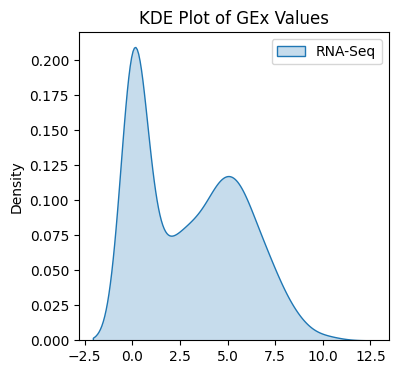

In [35]:
plot_adata_kde(adata, title="KDE Plot of GEx Values", sample_size=1000)


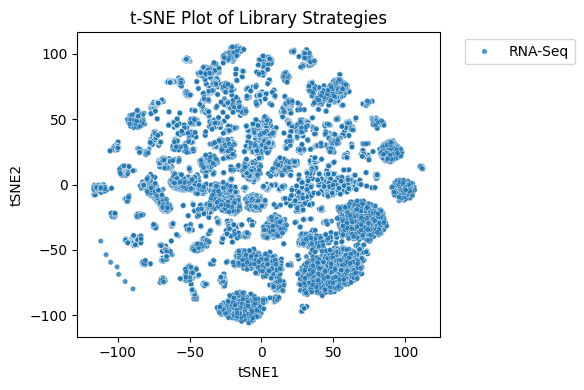

KeyError: 'library_strategy'

In [ ]:
import random, seaborn as sns
def plot_adata_tsne(adata: sc.AnnData, labels: list, title:str="t-SNE", sample:int=None)->None:
    
    X = adata.X
    labels = np.array(labels)
    if isinstance(X, np.ndarray):
        X = np.array(X)
    else:
        X = X.toarray()  # in case it's sparse

    # Fill NaNs
    X = np.nan_to_num(X, nan=0.0)

    if sample:
        _idxs = random.sample(range(X.shape[0]), sample)
        X = X[_idxs]
        labels = labels[_idxs]

    # Compute t-SNE
    tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
    X_tsne = tsne.fit_transform(X)

    # Build dataframe for plotting
    df = pd.DataFrame({
        "tSNE1": X_tsne[:, 0],
        "tSNE2": X_tsne[:, 1],
        "Type": labels
    })

    # --- Plot ---
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df,
        x="tSNE1",
        y="tSNE2",
        hue="Type",
        palette="tab10",
        s=15,
        alpha=0.8
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



def plot_adata_kde(adata:sc.AnnData, title:str="")->None:
    X_rna_seq = adata[adata.obs["library_strategy"] == "RNA-Seq"].X
    X_ma = adata[adata.obs["library_strategy"] == "Microarray"].X
    print(X_rna_seq.shape)
    print(X_rna_seq.flatten().shape)
    # sample from both distributions
    X_rna_seq_sample = random.sample(list(X_rna_seq.flatten()), 100)
    X_ma_sample = random.sample(list(X_ma.flatten()), 100)


    # plot
    plt.figure(figsize=(4, 4))
    sns.kdeplot(X_rna_seq_sample, label="RNA-Seq", fill=True)
    sns.kdeplot(X_ma_sample, label="Microarray", fill=True)
    plt.title(title)
    plt.legend()

plot_adata_tsne(adata, labels=adata.obs["library"].tolist(), title="t-SNE Plot of Library Strategies")


In [37]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

Number of DO leaves: 9018
Generated multilabel vectors for level 1 nodes with shape (21246, 50)
Cleaned multilabel vectors for top 50 nodes with shape (21246, 47)
554 samples	Node DOID:0014667 - disease of metabolism
518 samples	Node DOID:0050117 - disease by infectious agent
214 samples	Node DOID:0050155 - sensory system disease
422 samples	Node DOID:0050177 - monogenic disease
8477 samples	Node DOID:0050686 - organ system cancer
8103 samples	Node DOID:0050687 - cell type cancer
18 samples	Node DOID:0050735 - X-linked monogenic disease
201 samples	Node DOID:0050736 - autosomal dominant disease
158 samples	Node DOID:0050737 - autosomal recessive disease
359 samples	Node DOID:0050739 - autosomal genetic disease
9 samples	Node DOID:0060072 - benign neoplasm
9 samples	Node DOID:0060085 - organ system benign neoplasm
162 samples	Node DOID:0080000 - muscular disease
653 samples	Node DOID:0080001 - bone disease
27 samples	Node DOID:0080015 - physical disorder
352 samples	Node DOID:114 - hear

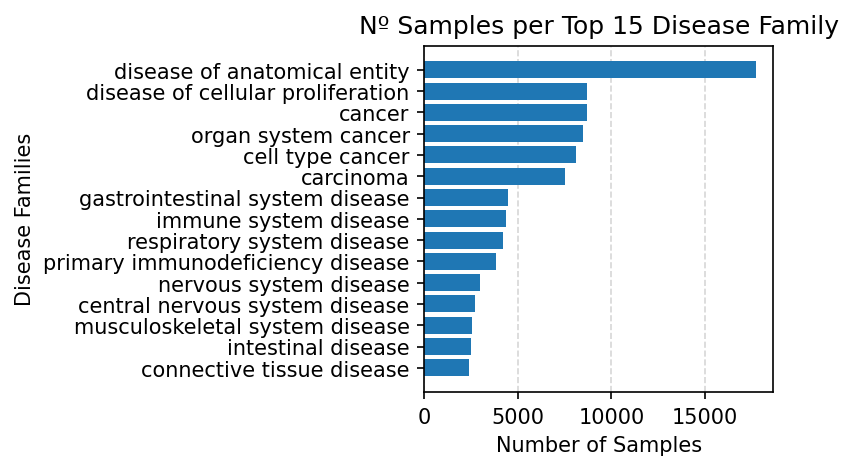

In [38]:
# viz top families
vz.plot_adata_top_families(adata, n_class_nodes=50, top_n=15)

In [39]:
from src.utils import utils as ut
df_info = ut.load_dsa_info()
dsaid_2_tissue = dict(zip(df_info["dsaid"], df_info["tissue"]))


adata.obs["tissue"] = adata.obs["dsaid"].map(dsaid_2_tissue)


/tmp/ipykernel_2788639/2714570909.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["tissue"] = adata.obs["dsaid"].map(dsaid_2_tissue)


In [40]:
# replace nans
adata.obs["tissue"].fillna("unknown", inplace=True)

/tmp/ipykernel_2788639/2525279044.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs["tissue"].fillna("unknown", inplace=True)


In [159]:
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

In [163]:
adata_tsne.obs["tissue"].value_counts() 

tissue
nan                               14048
Blood                              3438
Skin                               1548
Lung                               1476
Peripheral blood                   1472
                                  ...  
Immortalized primary myoblasts        6
Bladder                               6
Cerebrum                              5
Heart left ventricle                  4
Striatum                              4
Name: count, Length: 129, dtype: int64

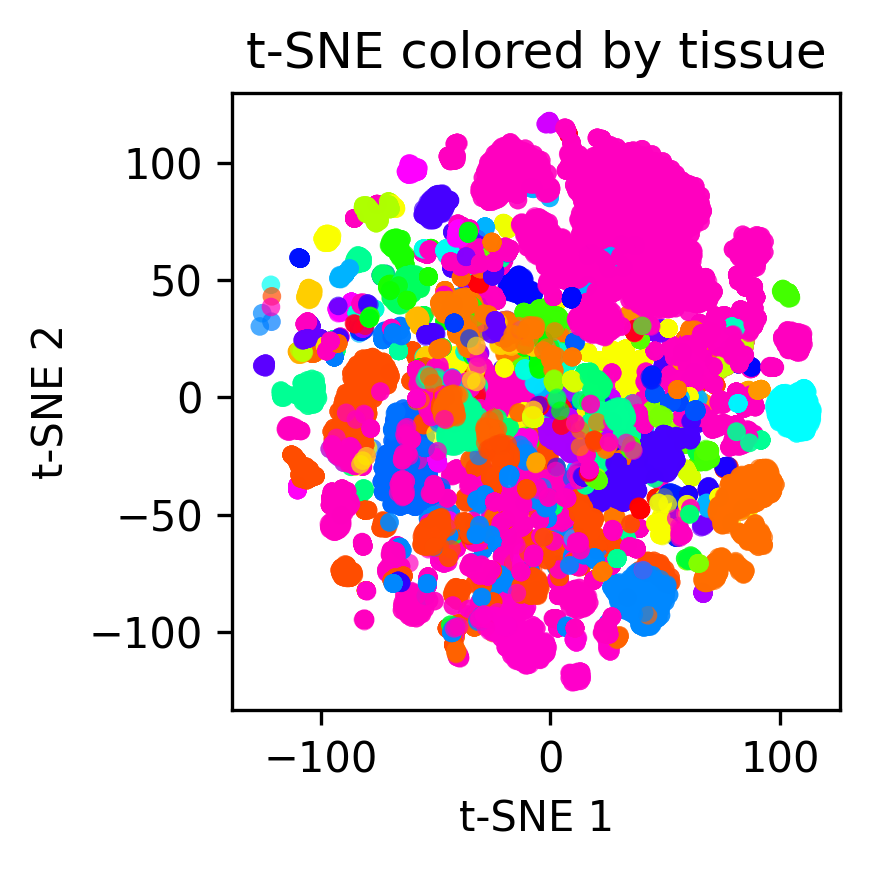

In [ ]:
X_tsne, adata_tsne = vz.transform_tsne(adata)


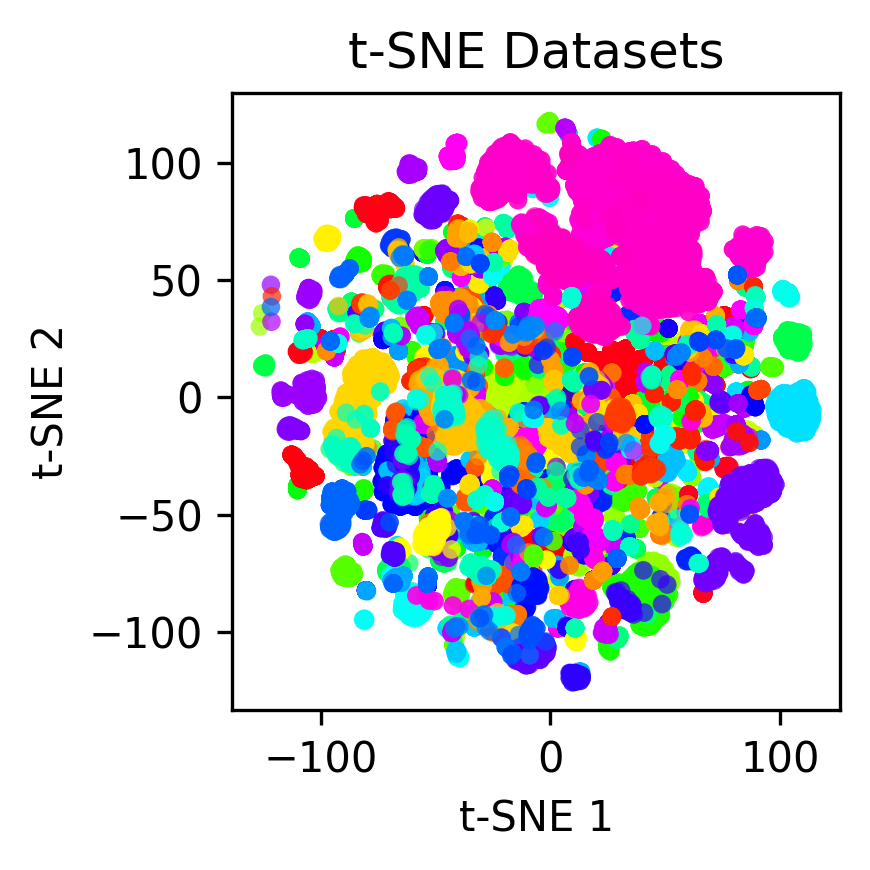

In [172]:
vz.plot_tsne_adata(X_tsne, adata_tsne, "dataset", title="t-SNE Datasets")

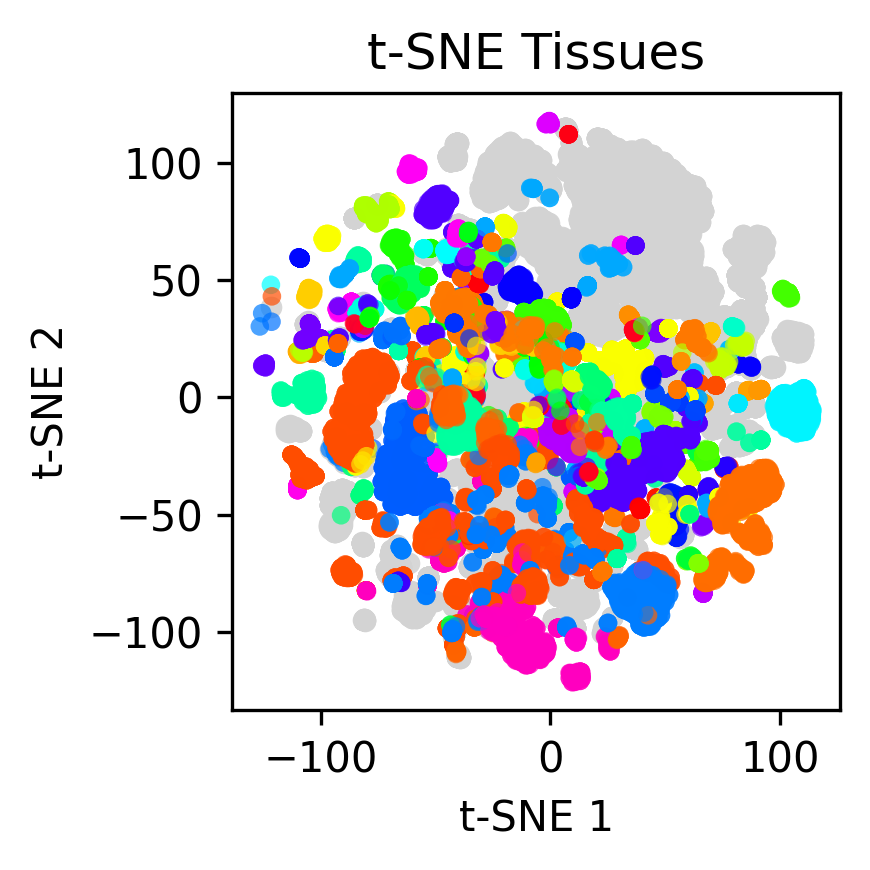

In [ ]:
vz.plot_tsne_adata(X_tsne, adata_tsne, "tissue", title="t-SNE Tissues")

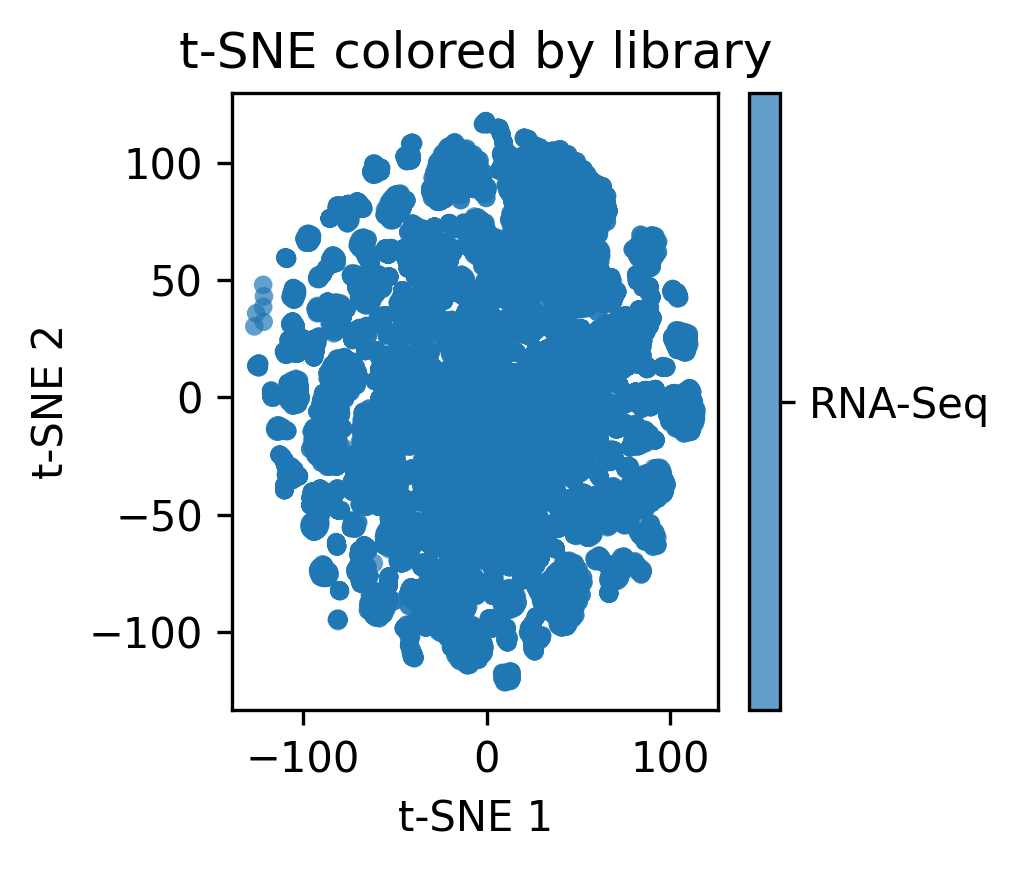

In [165]:
vz.plot_tsne_adata(X_tsne, adata_tsne, "library")


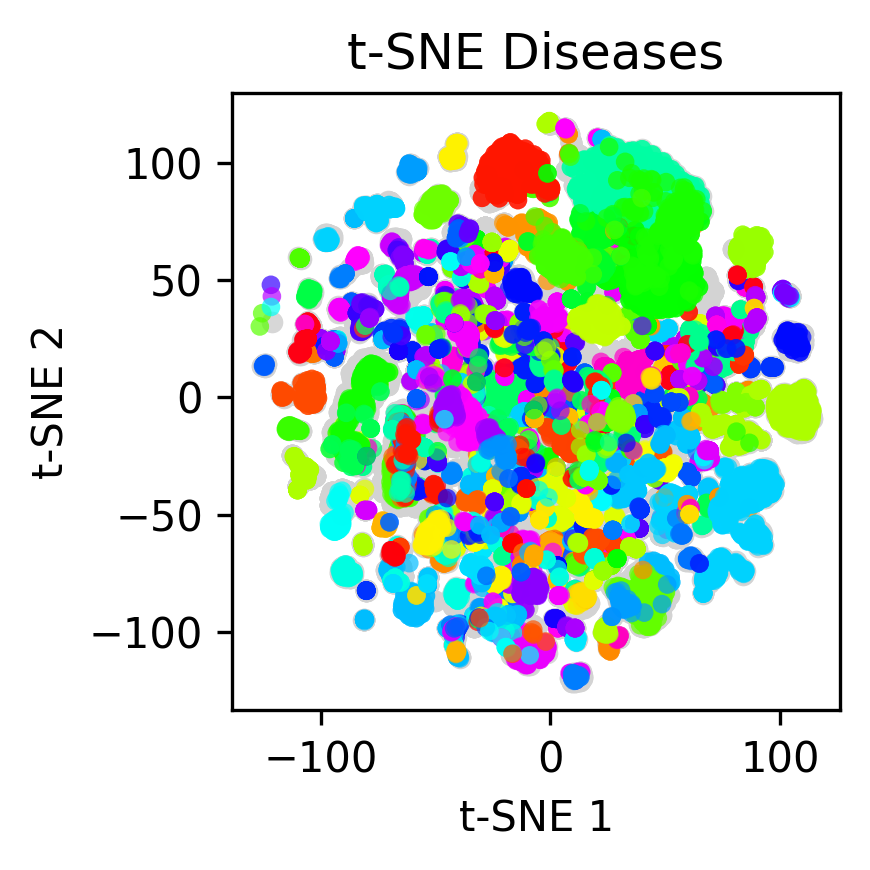

In [169]:
vz.plot_tsne_adata(X_tsne, adata_tsne, "doid_id", title="t-SNE Diseases")


In [135]:
adata.obs["disease"]=="Control"

0         True
1         True
2         True
3         True
4        False
         ...  
35621    False
35622    False
35623    False
35624    False
35625    False
Name: disease, Length: 35626, dtype: bool

In [44]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

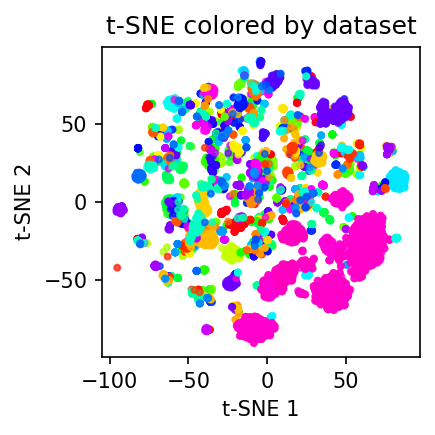

In [45]:
vz.plot_tsne_adata(adata, "dataset",sample_size=10000, dpi=150)

## Data Filtering Plots

In [ ]:
import sys
sys.path.append("../..")
from src.utils import utils as ut
df_info = ut.load_dsa_info()

counts = df_info["control_case_sample_count"].values
all_counts = [int(c.split("|")[0]) + int(c.split("|")[1]) for c in counts if "|" in c]
df_info = df_info.copy()
df_info["total_counts"] = all_counts

# filter by bulk
df_info = df_info.query(f"library_strategy in ['RNA-Seq' , 'Microarray']")
s_0 = df_info["total_counts"].sum()
d_0 = df_info["diseaseid"].nunique()
dt_0 = df_info["accession"].nunique()

# filter by species
df_info = df_info.query(f"organism == 'Homo sapiens'")
s_1 = df_info["total_counts"].sum()
d_1 = df_info["diseaseid"].nunique()
dt_1 = df_info["accession"].nunique()

# filter by mapping
_do_g = ut.load_do_graph()
_uml_2_doid = ut.get_umls_2_doid_mapping(_do_g)
df_info = df_info.query(f"diseaseid in {list(_uml_2_doid.keys())}")
s_2 = df_info["total_counts"].sum()
d_2 = df_info["diseaseid"].nunique()
dt_2 = df_info["accession"].nunique()

# filter by library stratergy
df_info = df_info.query(f"library_strategy in ['RNA-Seq']")
s_3 = df_info["total_counts"].sum()
d_3 = df_info["diseaseid"].nunique()
dt_3 = df_info["accession"].nunique()

# filter by sufficient data
s_4 = adata.X.shape[0]
d_4 = adata.obs["doid_id"].nunique() - 1 # remove control
dt_4 = adata.obs["dataset"].nunique()

In [61]:
df_info["total_counts"].sum()

46423

231153 1405 4875


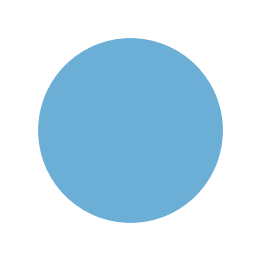

205395 1135 3544


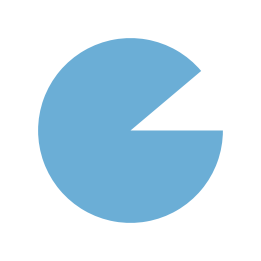

137539 591 2480


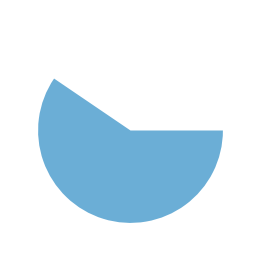

46423 340 873


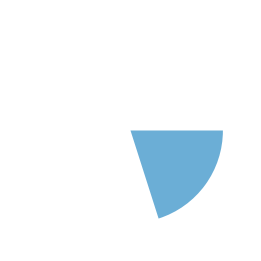

35626 132 660


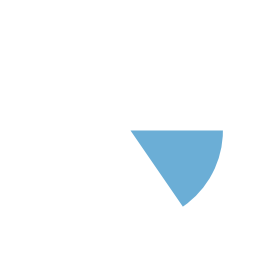

In [125]:
def plot_pie(x: list, colors:list, dpi:int=150):
    plt.figure(dpi=dpi, figsize=(2, 2))
    plt.pie(x, colors=colors, startangle=0)
    plt.show()
    
# plot pie charts
print(s_0, d_0, dt_0)
plot_pie([s_0], colors=["#6baed6"])
print(s_1, d_1, dt_1)
plot_pie([s_0-s_1, s_1], colors=["white", "#6baed6"])
print(s_2, d_2, dt_2)
plot_pie([s_0-s_2, s_2], colors=["white", "#6baed6"])
print(s_3, d_3, dt_3)
plot_pie([s_0-s_3, s_3], colors=["white", "#6baed6"])
print(s_4, d_4, dt_4)
plot_pie([s_0-s_4, s_4], colors=["white", "#6baed6"])



In [114]:
np.sum(adata.X == 0, axis=0)

array([ 3995, 13231,  3551, ...,  5480,  1412,  1143])